In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import string
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
from nltk.probability import FreqDist
import pymorphy3

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

In [4]:
with open('2012.txt', 'r') as file:
    data = file.read()

In [9]:
stop_words = stopwords.words('russian')
morph = pymorphy3.MorphAnalyzer()

In [11]:
def tokenize_text(raw_text: str):
    """Функция для токенизации текста
    :param raw_text: исходная текстовая строка
    """
    # Разбиение на сслова при помощи пробела
    words = raw_text.split()
    # Подготовка регулярного выражения для фильтрации символов
    re_punc = re.compile('[%s]' % re.escape(string.punctuation))
    # Удаление знаков препинания
    stripped = [re_punc.sub('', w) for w in words]
    # Приведение всех слов к нижнему регистру
    words_lower = [w.lower() for w in stripped]
    # Удаление оставшихся токенов, которые не являются буквами
    words_alpha = [word for word in words_lower if word.isalpha()]
    # Удаление стоп-слов    
    words_stop = [w for w in words_alpha if not w in stop_words]
    # Лемматизация    
    tokens = [morph.parse(token)[0].normal_form for token in words_stop]
    # Удалим короткие токены
    tokens = [word for word in tokens if len(word) > 2]
      
    return tokens

In [13]:
tokenized = tokenize_text(data)

In [15]:
all_words = FreqDist(tokenized)
print("Наиболлее популярные слова: ", all_words.most_common(100))
print("\nОбщее количество уникальных слов: ", len(all_words.keys()))

Наиболлее популярные слова:  [('страна', 51), ('развитие', 45), ('брикс', 39), ('наш', 32), ('который', 30), ('год', 27), ('международный', 27), ('также', 26), ('встреча', 24), ('глобальный', 23), ('сотрудничество', 23), ('экономика', 19), ('цель', 18), ('вопрос', 17), ('устойчивый', 16), ('экономический', 15), ('рост', 15), ('безопасность', 14), ('африка', 14), ('усилие', 14), ('банк', 14), ('финансовый', 14), ('конференция', 13), ('оон', 13), ('решение', 13), ('развивающийся', 13), ('государство', 13), ('индия', 12), ('интерес', 12), ('мир', 12), ('быть', 12), ('рамка', 12), ('проблема', 11), ('сообщество', 11), ('многосторонний', 11), ('достижение', 11), ('система', 11), ('результат', 11), ('поддерживать', 11), ('министр', 11), ('мера', 10), ('обеспечение', 10), ('отмечать', 10), ('мвф', 10), ('область', 10), ('приветствовать', 10), ('роль', 10), ('бразилия', 9), ('общий', 9), ('стабильность', 9), ('основа', 9), ('мировой', 9), ('являться', 9), ('считать', 9), ('призывать', 9), ('по

C:\Temp\ipykernel_9364\1563493910.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


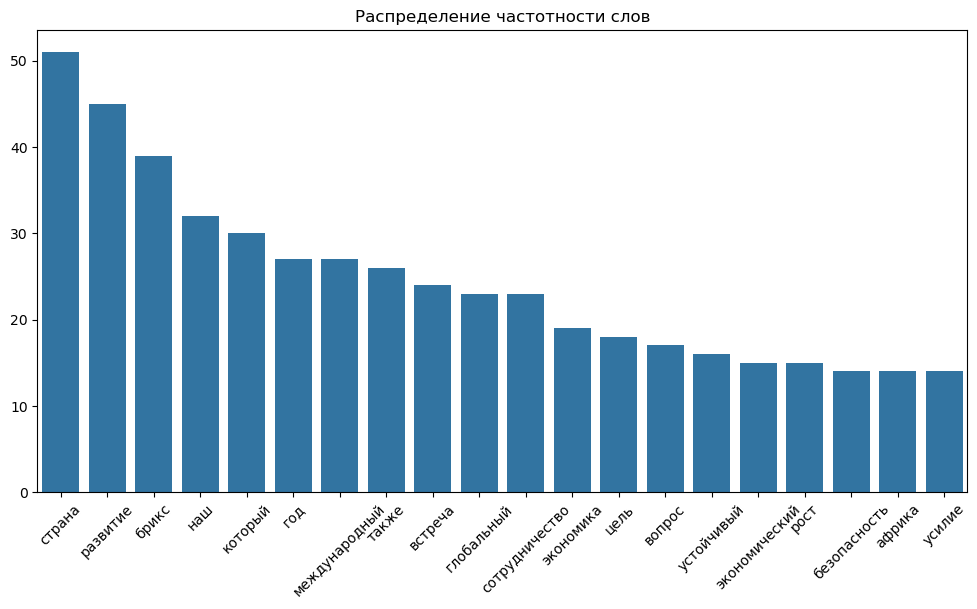

In [17]:
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

In [19]:
stop_words_ex = ['год','наш', 'который', 'также']
def stop_words_extra(text):
    return [w for w in text if not w in stop_words_ex]

In [21]:
tokens = stop_words_extra(tokenized)

C:\Temp\ipykernel_9364\3051857113.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


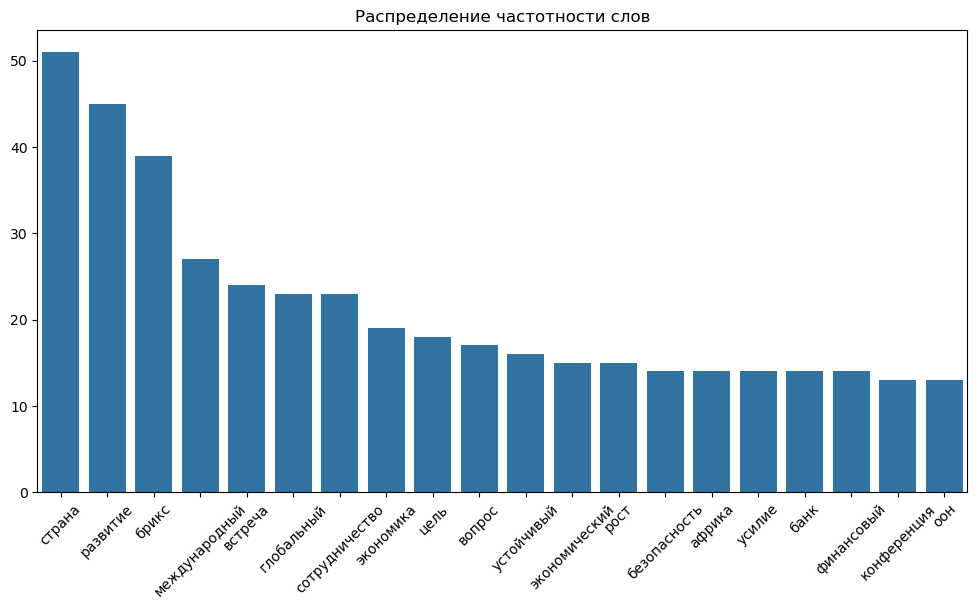

In [23]:
all_words = FreqDist(tokens)
count, words = [], []
for w in all_words.most_common(20):
    words.append(w[0])
    count.append(w[1])
fig,ax = plt.subplots(figsize = (12,6))
ax = sns.barplot(x=words,y=count)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_title ('Распределение частотности слов')
plt.show()

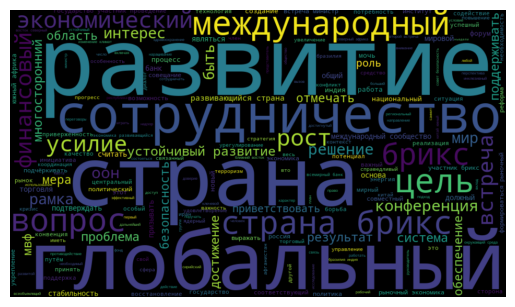

In [25]:
textt = ','.join(w for w in tokens)
wordcloud = WordCloud(width=950,height=550).generate(textt)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [27]:
# Приводим текст в векторное представление
tfidf_vect = TfidfVectorizer(max_df=1.0, min_df=2, stop_words=None)
doc_term_matrix = tfidf_vect.fit_transform(tokens)

### Латентное размещение Дерихле

In [30]:
LDA = LatentDirichletAllocation(n_components=2, random_state=42)
LDA.fit(doc_term_matrix)

LatentDirichletAllocation(n_components=2, random_state=42)

In [31]:
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['финансовый', 'безопасность', 'экономический', 'устойчивый', 'вопрос', 'цель', 'экономика', 'брикс', 'развитие', 'страна']


Top 10 words for topic #1:
['государство', 'оон', 'усилие', 'африка', 'банк', 'рост', 'сотрудничество', 'глобальный', 'встреча', 'международный']




In [34]:
LDA = LatentDirichletAllocation(n_components=3, random_state=42)
LDA.fit(doc_term_matrix)
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['индия', 'рамка', 'развивающийся', 'конференция', 'экономический', 'устойчивый', 'цель', 'экономика', 'развитие', 'страна']


Top 10 words for topic #1:
['сообщество', 'система', 'многосторонний', 'проблема', 'результат', 'оон', 'усилие', 'африка', 'встреча', 'международный']


Top 10 words for topic #2:
['решение', 'государство', 'банк', 'финансовый', 'безопасность', 'рост', 'вопрос', 'сотрудничество', 'глобальный', 'брикс']




### Неотрицательная матричная факторизация

In [36]:
nmf = NMF(n_components=2, random_state=42)
nmf.fit(doc_term_matrix )
for i,topic in enumerate(nmf.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vect.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['экономический', 'цель', 'роль', 'обеспечение', 'вопрос', 'рост', 'устойчивый', 'международный', 'брикс', 'страна']


Top 10 words for topic #1:
['усилие', 'безопасность', 'рост', 'экономический', 'вопрос', 'экономика', 'сотрудничество', 'глобальный', 'брикс', 'развитие']




Вывод: тематика декларации 2012 г. такжн посвящена общим вопросам глобального развития